
# Quarterback Decision–Making Model



### Imports

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, brier_score_loss, mean_squared_error, classification_report, brier_score_loss
from sklearn.calibration import calibration_curve
from scipy.stats import pearsonr

import joblib


from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier, MLPRegressor

import os


## Data Import and Processing


### Data Imports


In [ ]:
EXPERIMENT_NAME = "temporal"

# raw_features = pd.read_csv("../data/play_features_2.csv")
old_features = pd.read_csv("../data/play_features.csv")


outcomes = pd.read_csv("../data/play_outcomes_2.csv")


C:\Users\jesse\AppData\Local\Temp\ipykernel_37112\3121083287.py:4: DtypeWarning: Columns (0,3,4,5,6,7,8,9,10,11,14,15,16,17,18,19,20,21,22,25,26,27,28,29,30,31,32,33,36,37,38,39,40,41,42,43,44,47,48,49,50,51,52,53,54,55,58,59,60,61,62,63,64,65,66,69,70,71,72,73,74,75,76,77,80,81,82,83,84,85,86,87,88,91,92,93,94,95,96,97,98,99,102,103,104,105,106,107,108,109,110,113,114,115,116,117,118,119,120,121,124,125,126,127,128,129,130,131,132,135,136,137,138,139,140,141,142,143,146,147,148,149,150,151,152,153,154,157,158,159,160,161,162,163,164,165,168,169,170,171,172,173,174,175,176,179,180,181,182,183,184,185,186,187,190,191,192,193,194,195,196,197,198,201,202,203,204,205,206,207,208,209,212,213,214,215,216,217,218,219,220,223,224,225,226,227,228,229,230,231,234,235,236,237,238,239,240,241,242,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258) have mixed types. Specify dtype option on import or set low_memory=False.
  old_features = pd.read_csv("../data/play_features.csv")


In [4]:
features = old_features.rename(columns={"gameId": "game_id", "playId": "play_id", "frameId": "frame_id", "los": "line_of_scrimmage"})



In [5]:

# Load the player_play CSV (update the path as needed)
player_play = pd.read_csv("../data/player_play.csv")
players = pd.read_csv("../data/players.csv")

player_play = player_play.merge(
    players,
    how="left",
    left_on=["nflId"],
    right_on=["nflId",]
)
# Show the column names to confirm what the route column is called
print("Columns:", player_play.columns.tolist())

# Check which column contains route info (usually something like 'route')
# For now, let’s assume it’s 'route' — you can adjust after printing the columns

# Check distribution of positions with non-null routes
route_column = 'routeRan'  # Adjust this if it's different
positions_with_routes = player_play[player_play[route_column].notna()]["position"].value_counts()
print("Route Distribution by Position:\n", positions_with_routes)


Columns: ['gameId', 'playId', 'nflId', 'teamAbbr', 'hadRushAttempt', 'rushingYards', 'hadDropback', 'passingYards', 'sackYardsAsOffense', 'hadPassReception', 'receivingYards', 'wasTargettedReceiver', 'yardageGainedAfterTheCatch', 'fumbles', 'fumbleLost', 'fumbleOutOfBounds', 'assistedTackle', 'forcedFumbleAsDefense', 'halfSackYardsAsDefense', 'passDefensed', 'quarterbackHit', 'sackYardsAsDefense', 'safetyAsDefense', 'soloTackle', 'tackleAssist', 'tackleForALoss', 'tackleForALossYardage', 'hadInterception', 'interceptionYards', 'fumbleRecoveries', 'fumbleRecoveryYards', 'penaltyYards', 'penaltyNames', 'wasInitialPassRusher', 'causedPressure', 'timeToPressureAsPassRusher', 'getOffTimeAsPassRusher', 'inMotionAtBallSnap', 'shiftSinceLineset', 'motionSinceLineset', 'wasRunningRoute', 'routeRan', 'blockedPlayerNFLId1', 'blockedPlayerNFLId2', 'blockedPlayerNFLId3', 'pressureAllowedAsBlocker', 'timeToPressureAllowedAsBlocker', 'pff_defensiveCoverageAssignment', 'pff_primaryDefensiveCoverageMat

In [6]:
outcomes.dropna(subset=['end_frame', "game_id", "play_id"], inplace=True)
features.dropna(subset=["game_id", "play_id", 'frame_id'],  inplace=True)

for col in ["game_id", "play_id"]:
    outcomes[col] = pd.to_numeric(outcomes[col], errors='coerce')
    features[col] = pd.to_numeric(features[col], errors='coerce')
outcomes["end_frame"] = pd.to_numeric(outcomes["end_frame"], errors='coerce')


# Convert once, dropping rows where conversion failed
outcomes["end_frame"] = pd.to_numeric(outcomes["end_frame"], errors="coerce")

# Drop rows with any NaN in key columns
outcomes.dropna(subset=["end_frame", "game_id", "play_id"], inplace=True)

# Now it's safe to cast
outcomes["end_frame"] = outcomes["end_frame"].astype(int)
features.dropna(subset=["game_id", "play_id", 'frame_id'],  inplace=True)


features["frame_id"] = pd.to_numeric(features["frame_id"], errors='coerce').astype(int)

In [7]:
features = features.drop(columns=[c for c in features.columns if c in outcomes.columns and c not in ['game_id', 'play_id']])

features = features.merge(
    outcomes,
    how="left",
    on=["game_id", "play_id"],
)

features.drop(columns=["end_frame"], inplace=True)

### Add Target Recievers

In [8]:
features.shape

(294558, 279)

In [9]:
eligible_cols = [f"player_{i}_nflId" for i in range(6, 11)]

# Ensure proper types for merge
player_play["game_id"] = pd.to_numeric(player_play["gameId"], errors='coerce')
player_play["play_id"] = pd.to_numeric(player_play["playId"], errors='coerce')
player_play["nflId"] = pd.to_numeric(player_play["nflId"], errors='coerce')
# Convert eligible receiver nflIds to numeric
for i in range(6, 11):
    col = f"player_{i}_nflId"
    features[col] = pd.to_numeric(features[col], errors="coerce")


# Create a reduced version of player_play with just route info
routes_df = player_play[["game_id", "play_id", "nflId", route_column]]

# Loop over each eligible receiver slot and merge their route
for i in range(6, 11):
    player_col = f"player_{i}_nflId"
    route_col = f"player_{i}_route"

    # Merge route info based on (game_id, play_id, nflId)
    features = features.merge(
        routes_df,
        how="left",
        left_on=["game_id", "play_id", player_col],
        right_on=["game_id", "play_id", "nflId"]
    )

    # Save the route to a new column and drop the temp 'nflId' column
    features[route_col] = features[route_column]
    features.drop(columns=["nflId", route_column], inplace=True)


In [10]:
# One-hot encode each player's route and rename with prefix
for i in range(6, 11):
    route_col = f"player_{i}_route"
    dummies = pd.get_dummies(features[route_col], prefix=route_col)
    features = pd.concat([features, dummies], axis=1)


# Optional: drop original route columns

In [11]:
# Define the suffix to drop
suffix_to_drop = '_route'

# Create a new DataFrame excluding columns ending with the suffix
features = features[[col for col in features.columns if not col.endswith(suffix_to_drop)]]


In [12]:
game_state_cats = [
    "offense_formation",
    "receiver_alignment"

]

for cat in game_state_cats:
    dummies = pd.get_dummies(features[cat], prefix=cat)
    outcofeaturesmes = pd.concat([features, dummies], axis=1)

features.drop(game_state_cats, axis=1, inplace=True)

### Data Processing

In [13]:
# # Ensure numeric types


for col in [ "start_frame", 
            "down", "yards_to_go", "line_of_scrimmage", "yards_gained", "time_to_throw",
             "score_differential", "win_probability", "quarter", "seconds_to_half", 
             "play_clock_at_snap", "caused_pressure_count"]:
    features[col] = pd.to_numeric(features[col], errors='coerce')




In [14]:
# Filter valid pass results



features["frames_from_snap"] = features["frame_id"] - features["start_frame"]

In [15]:
# []
# df['col_obj'] = df['col_obj'].astype(int)

# Step 1: Convert 'object' type booleans to actual booleans (if needed)
# Example mapping — adapt to your data
bool_map = {
    'True': True, 'False': False,
    'true': True, 'false': False,
    'yes': True, 'no': False,
    '1': True, '0': False
}

for col in ["first_half", "play_action", "unblocked_pressure"]:
    if features[col].dtype == 'object':
        # Try to coerce to boolean using mapping or pandas conversion
        features[col] = features[col].map(bool_map).astype('bool', errors='ignore')

# Step 2: Convert all booleans to integers (0 or 1)
bool_cols = features.select_dtypes(include='bool').columns
features[bool_cols] = features[bool_cols].astype(int)

# Step 3 (optional): If you want to scale booleans, include them in scaler input
# Otherwise, you can exclude them and reattach later


In [16]:
def apply_horizontal_flip(df, flip_enabled=True):
    if not flip_enabled:
        return df.copy()

    df = df.copy()
    for i in range(23):
        df[f"player_{i}_y"] = 53.3 - df[f"player_{i}_y"]
        df[f"player_{i}_o"] = (180 - df[f"player_{i}_o"]) % 360
        df[f"player_{i}_dir"] = (180 - df[f"player_{i}_dir"]) % 360
    return df

def apply_gaussian_noise(df, features, std=0.5, noise_enabled=True):
    if not noise_enabled:
        return df.copy()

    df = df.copy()
    for feature in features:
        if feature in df.columns:
            df[feature] += np.random.normal(0, std, size=df.shape[0])
    return df


### Augment Features

In [17]:
# def augment_features(df, 
#                      flip=True, 
#                      add_noise=True, 
#                      mult_noise=False,
#                      noise_std_add=0.3,
#                      noise_std_mult=0.05):
#     df_aug = df.copy()

#     # 1) Flip horizontally across y-axis
#     if flip:
#         for i in range(23):
#             df_aug[f"player_{i}_y"] = 53.3 - df_aug[f"player_{i}_y"]
#             df_aug[f"player_{i}_o"] = (180 - df_aug[f"player_{i}_o"]) % 360
#             df_aug[f"player_{i}_dir"] = (180 - df_aug[f"player_{i}_dir"]) % 360

#     # 2) Gaussian additive noise (good for positions)
#     if add_noise:
#         noise_features = [c for c in df_aug.columns if any(x in c for x in ["_x","_y","_s","_a","_dis"])]
#         for c in noise_features:
#             df_aug[c] += np.random.normal(0, noise_std_add, size=len(df_aug))

#     # 3) Multiplicative noise (optional, good for angles)
#     if mult_noise:
#         angle_features = [c for c in df_aug.columns if "_o" in c or "_dir" in c]
#         for c in angle_features:
#             df_aug[c] *= np.random.normal(1, noise_std_mult, size=len(df_aug))

#     return df_aug

# # Usage:
# augmented_df = augment_features(features, flip=True, add_noise=True, mult_noise=True)
# features = pd.concat([features, augmented_df], axis=0).reset_index(drop=True)


In [18]:
import torch
import numpy as np

def augment_tensor_features(tensor,
                            feature_names,
                            flip_prob=0.5,
                            noise_add_prob=0.5,
                            mult_noise_prob=0.5,
                            noise_std_add=0.3,
                            noise_std_mult=0.05,
                            flip_features=None,
                            rotate_features=None):
    """
    Apply dynamic augmentation to a feature tensor.
    
    Args:
        tensor (torch.Tensor): shape (batch_size, num_features)
        feature_names (list[str]): feature names matching tensor dim 1
        flip_prob (float): probability to apply y-flip
        noise_add_prob (float): probability to add Gaussian noise
        mult_noise_prob (float): probability to apply multiplicative noise
        noise_std_add (float): std dev for additive noise
        noise_std_mult (float): std dev for multiplicative noise
        flip_features (list[str]): substrings of features to y-flip (e.g., ['_y'])
        rotate_features (list[str]): substrings of angle features to rotate (e.g., ['_o', '_dir'])
    
    Returns:
        torch.Tensor: Augmented tensor
    """
    tensor_aug = tensor.clone()

    # Boolean masks for each type
    feature_names = np.array(feature_names)
    flip_mask = torch.tensor([any(k in name for k in flip_features or []) for name in feature_names], dtype=torch.bool)
    rotate_mask = torch.tensor([any(k in name for k in rotate_features or []) for name in feature_names], dtype=torch.bool)
    add_noise_mask = torch.tensor([any(k in name for k in ['_x','_y','_s','_a','_dis']) for name in feature_names], dtype=torch.bool)
    mult_noise_mask = torch.tensor([any(k in name for k in ['_o','_dir']) for name in feature_names], dtype=torch.bool)

    # Apply flipping (if chosen)
    if np.random.rand() < flip_prob:
        tensor_aug[:, flip_mask] = 53.3 - tensor_aug[:, flip_mask]
        if rotate_features:
            tensor_aug[:, rotate_mask] = (180 - tensor_aug[:, rotate_mask]) % 360

    # Additive Gaussian noise
    if np.random.rand() < noise_add_prob:
        noise = torch.randn_like(tensor_aug[:, add_noise_mask]) * noise_std_add
        tensor_aug[:, add_noise_mask] += noise

    # Multiplicative noise (for angles)
    if np.random.rand() < mult_noise_prob:
        mult_noise = torch.randn_like(tensor_aug[:, mult_noise_mask]) * noise_std_mult + 1
        tensor_aug[:, mult_noise_mask] *= mult_noise

    return tensor_aug


In [19]:
list_of_columns_with_nan = features.columns[features.isna().any()].tolist()
features.fillna(value=0,inplace=True)

C:\Users\jesse\AppData\Local\Temp\ipykernel_37112\3193872592.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features.fillna(value=0,inplace=True)


### Drop Unnecessary Features

In [20]:
# Drop non-numeric, identifier, or irrelevant fields
cols_to_drop = [col for col in features.columns 
                if col.endswith("displayName_x") or col.endswith("nflId") 
                or col.endswith("_position") or col.endswith("displayName_y")
                or col in ["start_frame", "end_frame", "game_id", "play_id", "frame_id",
                           "yards_gained", "pass_result", "play_type", "targeted_receiver_nflId",
                           "player_22_nflId", "player_22_position", "player_22_o", "player_22_dir", 
                           "time_to_throw", "targeted_receiver", "player22_dir", "player22_position", 
                           "player22_displayName_y", "time_to_throw", "dropback_type", "unblocked_pressure", 
                           "pff_pass_coverage", "pff_man_zone", "caused_pressure_count", ]]




In [21]:
features["pass_result"] = features["pass_result"].apply(
    lambda x: "P" if x in {"C", "I", "IN"} else x
)

In [30]:
# Classification dataset
clf_df = features.dropna(subset=["pass_result"]).copy()

X_clf = clf_df.drop(columns=cols_to_drop)
y_clf = clf_df["pass_result"]
for col in X_clf.select_dtypes(include=['object']).columns:
    X_clf[col] = pd.to_numeric(X_clf[col], errors='coerce')
le = LabelEncoder()
y_clf_enc = le.fit_transform(y_clf)  # ["C", "I", "IN"] → [0, 1, 2]

# Regression dataset (only completions)
reg_df = features[features["pass_result"] != "P"].copy()
for col in reg_df.select_dtypes(include=['object']).columns:
    reg_df[col] = pd.to_numeric(reg_df[col], errors='coerce')
X_reg = reg_df.drop(columns=cols_to_drop)
y_reg = reg_df["yards_gained"]

In [31]:
cols_to_drop_2 = [col for col in features.columns 
                if col.endswith("displayName_x") 
                or col.endswith("_position") or col.endswith("displayName_y")
                or col in ["start_frame", "end_frame", 
                           "play_type", "targeted_receiver_nflId",
                           "player_22_nflId", "player_22_position", "player_22_o", "player_22_dir", 
                           "time_to_throw", "targeted_receiver", "player22_dir", "player22_position", 
                           "player22_displayName_y"]]


In [32]:


column_dtypes = X_clf.dtypes

# Filter for columns that are not float64
# non_float64_columns = column_dtypes[(column_dtypes != np.float64) & (column_dtypes != bool)]
non_float64_columns = column_dtypes[(column_dtypes == object)]

for i in non_float64_columns.index:
  print(i)

In [33]:
summary_stats = X_reg.describe().T[["min","max"]]
summary_stats["range"] = summary_stats["max"] - summary_stats["min"]
print(summary_stats.head(20))  # first 20 features

# Addative      
# Multiplicative

                       min     max   range
player_0_x            0.56  110.49  109.93
player_0_x_relative -28.03    6.46   34.49
player_0_y           -0.25   53.38   53.63
player_0_s            0.00    9.82    9.82
player_0_a            0.00   11.36   11.36
player_0_dis          0.00    0.99    0.99
player_0_o            0.03  359.98  359.95
player_0_dir          0.00  359.98  359.98
player_1_x            7.67  108.55  100.88
player_1_x_relative -31.44   20.60   52.04
player_1_y            4.43   50.33   45.90
player_1_s            0.00    8.46    8.46
player_1_a            0.00    7.68    7.68
player_1_dis          0.00    0.85    0.85
player_1_o            0.01  359.97  359.96
player_1_dir          0.01  360.00  359.99
player_2_x            3.19  107.97  104.78
player_2_x_relative -50.05    4.45   54.50
player_2_y            8.59   48.40   39.81
player_2_s            0.00    6.95    6.95


### Train Test Split

In [34]:
# 5) Scale features
scaler_c = StandardScaler().fit(X_clf)

Xc_s = scaler_c.transform(X_clf)

Xr_s = scaler_c.transform(X_reg)

joblib.dump(scaler_c, "../models/scaler_c.pkl") #saved
print("Scaler saved!")


Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc_s, y_clf_enc, test_size=0.2, random_state=42, stratify=y_clf_enc
)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr_s, y_reg, test_size=0.2, random_state=42
)

Scaler saved!


In [ ]:
# #export features for the animation
# import pandas as pd
# import numpy as np

# # 1️⃣ Create the dataframe with columns you want to export (keeps extra metadata)
# export_features = features.drop(columns=cols_to_drop_2).copy()

# # 2️⃣ Identify which columns in export_features were actually used for training
# train_feature_cols = X_clf.columns.intersection(export_features.columns)

# # 3️⃣ Scale ONLY the training columns using the scaler trained on X_clf
# scaled_values = scaler_c.transform(export_features[train_feature_cols])

# # Replace original training feature columns with their scaled versions
# export_features.loc[:, train_feature_cols] = scaled_values

# print("✅ export_features created with scaled training features & unscaled metadata columns")

# # Optional: Save it for later use
# # export_features.to_csv("../data/export_features.csv", index=False)
# # print("✅ Saved to ../data/export_features.csv")


C:\Users\jesse\AppData\Local\Temp\ipykernel_37112\2290818748.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1.19510166 1.19510166 1.19510166 ... 1.19510166 1.19510166 1.19510166]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  export_features.loc[:, train_feature_cols] = scaled_values
C:\Users\jesse\AppData\Local\Temp\ipykernel_37112\2290818748.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.79058213  0.79058213  0.79058213 ... -1.23110468 -1.23110468
 -1.23110468]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  export_features.loc[:, train_feature_cols] = scaled_values
C:\Users\jesse\AppData\Local\Temp\ipykernel_37112\2290818748.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. 

✅ export_features created with scaled training features & unscaled metadata columns


C:\Users\jesse\AppData\Local\Temp\ipykernel_37112\2290818748.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.22410373 -0.22410373 -0.22410373 ... -0.22410373 -0.22410373
 -0.22410373]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  export_features.loc[:, train_feature_cols] = scaled_values
C:\Users\jesse\AppData\Local\Temp\ipykernel_37112\2290818748.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.03760695 -0.03760695 -0.03760695 ... -0.03760695 -0.03760695
 -0.03760695]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  export_features.loc[:, train_feature_cols] = scaled_values
C:\Users\jesse\AppData\Local\Temp\ipykernel_37112\2290818748.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of p

In [36]:
# reg_model(torch.tensor(Xc_s[0], dtype=torch.float32).unsqueeze(


In [37]:


# Convert to torch tensors
Xc_train_tensor = torch.tensor(Xc_train, dtype=torch.float32)
Xc_test_tensor  = torch.tensor(Xc_test, dtype=torch.float32)
yc_train_tensor = torch.tensor(yc_train, dtype=torch.long)
yc_test_tensor  = torch.tensor(yc_test, dtype=torch.long)

Xr_train_tensor = torch.tensor(Xr_train, dtype=torch.float32)
Xr_test_tensor  = torch.tensor(Xr_test, dtype=torch.float32)
yr_train_tensor = torch.tensor(yr_train.values, dtype=torch.float32).unsqueeze(1)
yr_test_tensor  = torch.tensor(yr_test.values, dtype=torch.float32).unsqueeze(1)

In [38]:
class FootballDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, feature_names, augment=False, augment_params=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = y  # or float32 for regression
        self.feature_names = feature_names
        self.augment = augment
        self.augment_params = augment_params or {}

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]

        if self.augment:
            x = augment_tensor_features(
                x.unsqueeze(0),  # add batch dim
                self.feature_names,
                **self.augment_params
            ).squeeze(0)  # remove batch dim

        return x, y


In [39]:
flip_features = [col for col in X_clf.columns if col.endswith('_y')]
rotate_features = [col for col in X_clf.columns if col.endswith('_o') or col.endswith('_dir')]


augment_params = {
    "flip_prob": 0.5,
    "noise_add_prob": 0.5,
    "mult_noise_prob": 0.3,
    "noise_std_add": 0.2,
    "noise_std_mult": 0.03,
    "flip_features": flip_features,
    "rotate_features": rotate_features
}


Xc_train_dataset = FootballDataset(Xc_train_tensor, yc_train_tensor, X_clf.columns.tolist(), augment=True, augment_params=augment_params)
Xc_val_dataset = FootballDataset(Xc_test_tensor, yc_test_tensor, X_clf.columns.tolist(), augment=False)

Xr_train_dataset = FootballDataset(Xr_train_tensor, yr_train_tensor, X_clf.columns.tolist(), augment=True, augment_params=augment_params)
Xr_val_dataset = FootballDataset(Xr_test_tensor, yr_test_tensor, X_clf.columns.tolist(), augment=False)


C:\Users\jesse\AppData\Local\Temp\ipykernel_37112\2137398372.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=torch.float32)


## Model Architecture

In [40]:
class Net(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Net, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 230),
            nn.ReLU(),
            nn.BatchNorm1d(230),

            nn.Dropout(0.6),
            nn.Linear(230, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),

            nn.Dropout(0.6),
            nn.Linear(256, 128),
            nn.ReLU(),
            
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.layers(x)

In [41]:
# Model 1 (classification)
clf_model = Net(Xc_train.shape[1], 3)
optimizer_clf = optim.Adam(clf_model.parameters(), lr=1e-4, weight_decay=1e-5)
criterion_clf = nn.CrossEntropyLoss(label_smoothing=0.05)

# (Train loop + loss tracking and test evaluation)

## 7. 🚂 Train Regressor
# Model 2 (regression)
reg_model = Net(Xr_train.shape[1], 1)
optimizer_reg = optim.Adam(reg_model.parameters(), lr=1e-3)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

criterion_reg = nn.MSELoss()
# criterion_reg = nn.SmoothL1Loss(beta=1.0) #fixme


# class LabelSmoothingLoss(nn.Module):
#     def __init__(self, classes, smoothing=0.1):
#         super(LabelSmoothingLoss, self).__init__()
#         self.confidence = 1.0 - smoothing
#         self.smoothing = smoothing
#         self.cls = classes
#         self.log_softmax = nn.LogSoftmax(dim=-1)

#     def forward(self, x, target):
#         log_probs = self.log_softmax(x)
#         with torch.no_grad():
#             true_dist = torch.zeros_like(log_probs)
#             true_dist.fill_(self.smoothing / (self.cls - 1))
#             true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
#         return torch.mean(torch.sum(-true_dist * log_probs, dim=-1))

# # Example use:
# criterion_clf = LabelSmoothingLoss(classes=3, smoothing=0.1)



<!-- ## Training -->

### Classification Model Training


In [42]:


# train_losses, test_losses = [], []
# train_acc, test_acc = [], []


# for epoch in range(30):
#     clf_model.train()
#     optimizer_clf.zero_grad()
#     outputs = clf_model(Xc_train_tensor)
    
#     loss = criterion_clf(outputs, yc_train_tensor)
#     loss.backward()
#     optimizer_clf.step()
#     train_losses.append(loss.item())

#     # get accuracy
#     class_probs = torch.softmax(outputs, dim=1)
#     class_preds = torch.argmax(class_probs, dim=1)
#     total_correct = (class_preds == yc_train_tensor).sum().item()
#     total_class = yc_train_tensor.size(0)
#     train_acc.append(total_correct / total_class)

#     # Evaluate
#     clf_model.eval()
#     with torch.no_grad():
#         val_outputs = clf_model(Xc_test_tensor)
#         val_loss = criterion_clf(val_outputs, yc_test_tensor).item()
#         test_losses.append(val_loss)
#             # get accuracy
#         class_probs = torch.softmax(val_outputs, dim=1)
#         class_preds = torch.argmax(class_probs, dim=1)
#         total_correct = (class_preds == yc_test_tensor).sum().item()
#         total_class = yc_test_tensor.size(0)
#         test_acc.append(total_correct / total_class)


#     print(f"Epoch {epoch+1}: Train Loss = {loss.item():.4f}, Train Accuracy = {train_acc[-1]:.4f}, Test Loss = {val_loss:.4f}, Test Accuracy = {total_correct / total_class:.4f}")

# # Save model



In [43]:
from torch.utils.data import TensorDataset, DataLoader

# Create DataLoaders
batch_size = 128  # try 256 or 512 later to see impact


train_loader = DataLoader(Xc_train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(Xc_val_dataset, batch_size=batch_size)

train_losses, test_losses = [], []
train_acc, test_acc = [], []
best_val_loss = 100000
patience = 15
count = 0

for epoch in range(100):
    clf_model.train()
    total_train_loss = 0
    correct_train = 0
    total_samples = 0

    for xb, yb in train_loader:
        optimizer_clf.zero_grad()
        outputs = clf_model(xb)
        loss = criterion_clf(outputs, yb)
        loss.backward()
        optimizer_clf.step()
        
        total_train_loss += loss.item() * xb.size(0)
        preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)
        correct_train += (preds == yb).sum().item()
        total_samples += yb.size(0)

    avg_train_loss = total_train_loss / total_samples
    avg_train_acc = correct_train / total_samples
    train_losses.append(avg_train_loss)
    train_acc.append(avg_train_acc)

    # Evaluation
    clf_model.eval()
    total_val_loss = 0
    correct_val = 0
    val_samples = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = clf_model(xb)
            loss = criterion_clf(outputs, yb)
            total_val_loss += loss.item() * xb.size(0)
            preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)
            correct_val += (preds == yb).sum().item()
            val_samples += yb.size(0)

    avg_val_loss = total_val_loss / val_samples
    avg_val_acc = correct_val / val_samples
    test_losses.append(avg_val_loss)
    test_acc.append(avg_val_acc)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
    else:
        count += 1
        if count > patience:
            print("early stopping")
            break

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Train Accuracy = {avg_train_acc:.4f}, Test Loss = {avg_val_loss:.4f}, Test Accuracy = {avg_val_acc:.4f}")


Epoch 1: Train Loss = 0.5750, Train Accuracy = 0.8479, Test Loss = 0.4058, Test Accuracy = 0.9059
Epoch 2: Train Loss = 0.5126, Train Accuracy = 0.8708, Test Loss = 0.3895, Test Accuracy = 0.9106
Epoch 3: Train Loss = 0.5032, Train Accuracy = 0.8734, Test Loss = 0.3777, Test Accuracy = 0.9138
Epoch 4: Train Loss = 0.4979, Train Accuracy = 0.8750, Test Loss = 0.3722, Test Accuracy = 0.9163
Epoch 5: Train Loss = 0.4918, Train Accuracy = 0.8771, Test Loss = 0.3595, Test Accuracy = 0.9188
Epoch 6: Train Loss = 0.4891, Train Accuracy = 0.8781, Test Loss = 0.3526, Test Accuracy = 0.9222
Epoch 7: Train Loss = 0.4841, Train Accuracy = 0.8798, Test Loss = 0.3433, Test Accuracy = 0.9266
Epoch 8: Train Loss = 0.4802, Train Accuracy = 0.8813, Test Loss = 0.3339, Test Accuracy = 0.9303
Epoch 9: Train Loss = 0.4768, Train Accuracy = 0.8825, Test Loss = 0.3211, Test Accuracy = 0.9353
Epoch 10: Train Loss = 0.4725, Train Accuracy = 0.8838, Test Loss = 0.3136, Test Accuracy = 0.9383
Epoch 11: Train Los

KeyboardInterrupt: 

### Regression Model Training


In [ ]:


# reg_train_losses, reg_test_losses = [], []

# for epoch in range(100):
#     reg_model.train()
#     optimizer_reg.zero_grad()
#     preds = reg_model(Xr_train_tensor)
#     loss = criterion_reg(preds, yr_train_tensor)
#     loss.backward()
#     optimizer_reg.step()
#     reg_train_losses.append(loss.item())

#     # Evaluate
#     reg_model.eval()
#     with torch.no_grad():
#         val_preds = reg_model(Xr_test_tensor)
#         val_loss = criterion_reg(val_preds, yr_test_tensor).item()
#         reg_test_losses.append(val_loss)

#     print(f"Epoch {epoch+1}: Train Loss = {loss.item():.4f}, Test Loss = {val_loss:.4f}")

# # Save model


In [44]:
from torch.utils.data import TensorDataset, DataLoader

# Create DataLoaders
batch_size = 128  # try 256 or 512 later to see impact
patience = 10
count = 0
best_val_loss = 100000


train_loader = DataLoader(Xr_train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(Xr_val_dataset, batch_size=batch_size)

reg_train_losses, reg_test_losses = [], []

for epoch in range(300):
    reg_model.train()
    total_train_loss = 0
    correct_train = 0
    total_samples = 0

    for xb, yb in train_loader:
        optimizer_reg.zero_grad()
        outputs = reg_model(xb)
        loss = criterion_reg(outputs, yb)
        loss.backward()
        optimizer_reg.step()
        
        total_train_loss += loss.item() * xb.size(0)
        total_samples += xb.size(0)


    avg_train_loss = total_train_loss / total_samples
    reg_train_losses.append(avg_train_loss)

    # Evaluation
    reg_model.eval()
    total_val_loss = 0
    val_samples = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = reg_model(xb)
            loss = criterion_reg(outputs, yb)
            total_val_loss += loss.item() * xb.size(0)
            val_samples += yb.size(0)

    avg_val_loss = total_val_loss / val_samples
    reg_test_losses.append(avg_val_loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
    else:
        count += 1
        if count > patience:
            print("early stopping")
            break

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f},  Test Loss = {avg_val_loss:.4f}")


Epoch 1: Train Loss = 63.5828,  Test Loss = 25.5560
Epoch 2: Train Loss = 55.2789,  Test Loss = 21.0201
Epoch 3: Train Loss = 53.6156,  Test Loss = 18.8834
Epoch 4: Train Loss = 53.1288,  Test Loss = 16.4874
Epoch 5: Train Loss = 51.3824,  Test Loss = 17.4665
Epoch 6: Train Loss = 50.7877,  Test Loss = 17.5016
Epoch 7: Train Loss = 51.4473,  Test Loss = 17.6512
Epoch 8: Train Loss = 49.5895,  Test Loss = 17.8967
Epoch 9: Train Loss = 41.6346,  Test Loss = 14.0267
Epoch 10: Train Loss = 40.2461,  Test Loss = 13.7244
Epoch 11: Train Loss = 40.2495,  Test Loss = 11.1041
Epoch 12: Train Loss = 38.5742,  Test Loss = 18.4752


KeyboardInterrupt: 

In [45]:
EXPERIMENT_NAME = "temporal"


In [46]:
torch.save(clf_model.state_dict(), f"../models/throw_classifier_{EXPERIMENT_NAME}.pt")

torch.save(reg_model.state_dict(), f"../models/throw_regressor_v_{EXPERIMENT_NAME}.pt")


In [47]:
# Load the classifier model weights
# clf_model.load_state_dict(torch.load("../models/throw_classifier_best.pt"))

# Load the regression model weights
# reg_model.load_state_dict(torch.load("../models/throw_regressor_v_{EXPERIMENT_NAME}_best.pt"))


## Plots

### Training Loss Plots

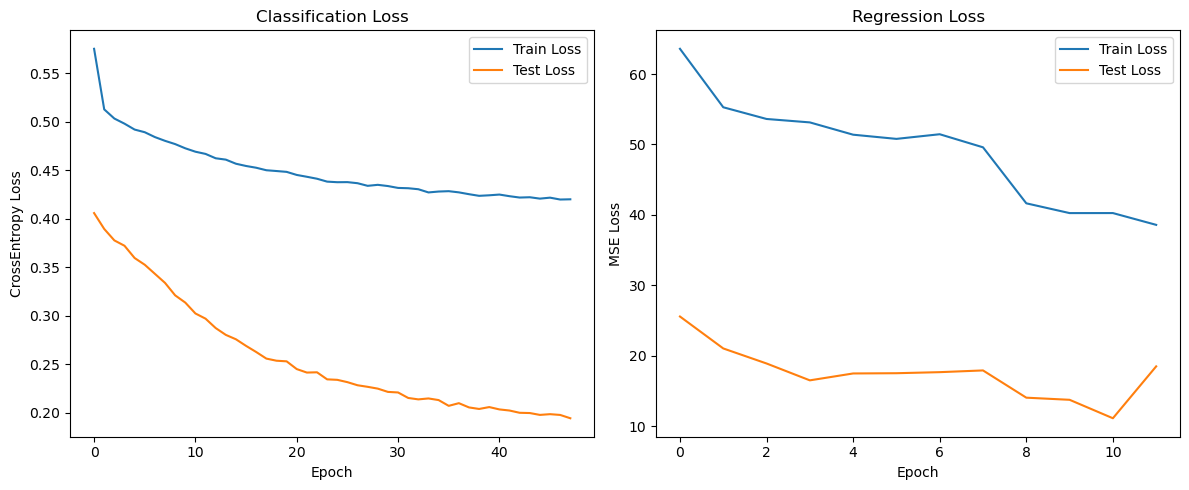

In [48]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Classification Loss")
plt.xlabel("Epoch")
plt.ylabel("CrossEntropy Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(reg_train_losses, label="Train Loss")
plt.plot(reg_test_losses, label="Test Loss")
plt.title("Regression Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()

plt.tight_layout()
plt.savefig(f"../outputs/images/training_loss_{EXPERIMENT_NAME}.png")
plt.show()



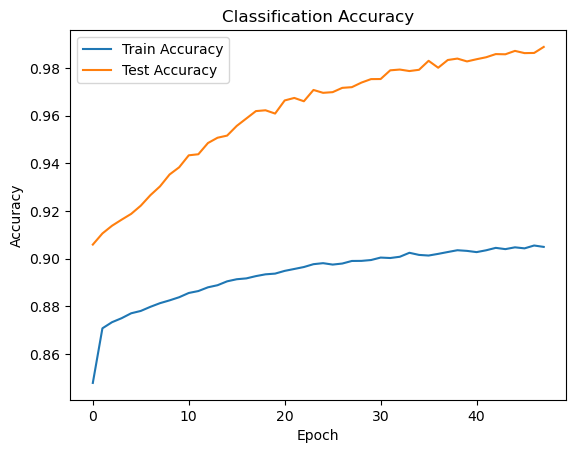

In [49]:
plt.plot(train_acc, label="Train Accuracy")
plt.plot(test_acc, label="Test Accuracy")
plt.title("Classification Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig(f"../outputs/images/training_accuracy_{EXPERIMENT_NAME}.png")

plt.show()


### Classification Prediction and Calibration


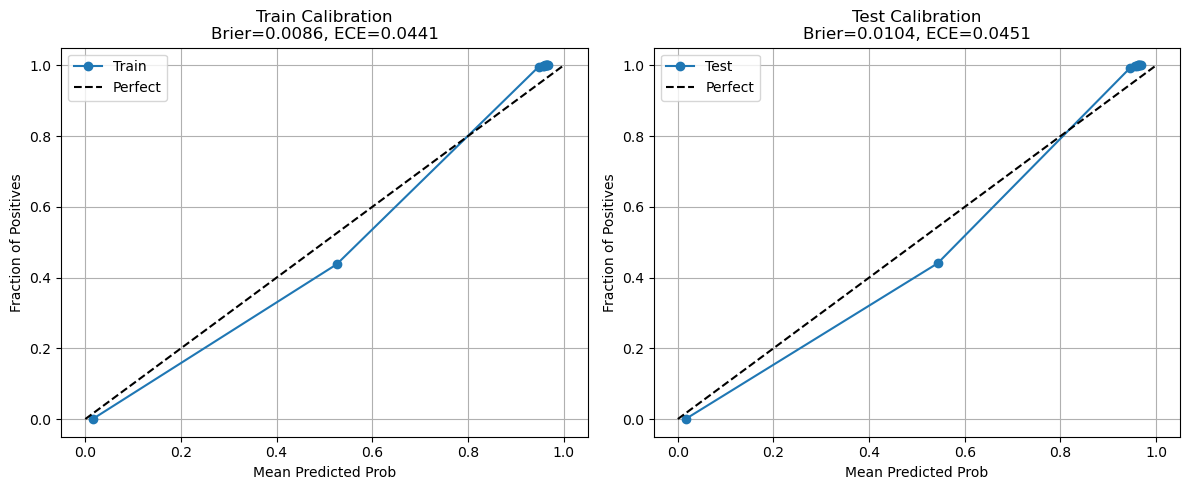

In [50]:
from sklearn.metrics import brier_score_loss
import numpy as np

def compute_ece(y_true, y_prob, n_bins=10):
    """Compute Expected Calibration Error (ECE) for binary probs"""
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1

    ece = 0.0
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() > 0:
            avg_conf = y_prob[mask].mean()
            avg_acc = y_true[mask].mean()
            ece += (mask.sum() / len(y_prob)) * abs(avg_acc - avg_conf)
    return ece

# === Model predictions (already have this part) ===
clf_model.eval()
with torch.no_grad():
    train_probs = torch.softmax(clf_model(Xc_train_tensor), dim=1).numpy()
    test_probs  = torch.softmax(clf_model(Xc_test_tensor), dim=1).numpy()

train_true_complete = (yc_train == 0).astype(int)
test_true_complete  = (yc_test == 0).astype(int)

train_pred_complete = train_probs[:, 0]  # prob of "Complete"
test_pred_complete  = test_probs[:, 0]

# === Compute metrics ===
brier_train = brier_score_loss(train_true_complete, train_pred_complete)
ece_train   = compute_ece(train_true_complete, train_pred_complete, n_bins=10)

brier_test  = brier_score_loss(test_true_complete, test_pred_complete)
ece_test    = compute_ece(test_true_complete, test_pred_complete, n_bins=10)

# === Calibration curves ===
from sklearn.calibration import calibration_curve
frac_pos_train, mean_pred_train = calibration_curve(train_true_complete, train_pred_complete, n_bins=10, strategy='quantile')
frac_pos_test, mean_pred_test   = calibration_curve(test_true_complete, test_pred_complete, n_bins=10, strategy='quantile')

# === Plot ===
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mean_pred_train, frac_pos_train, "o-", label="Train")
plt.plot([0, 1], [0, 1], "k--", label="Perfect")
plt.title(f"Train Calibration\nBrier={brier_train:.4f}, ECE={ece_train:.4f}")
plt.xlabel("Mean Predicted Prob")
plt.ylabel("Fraction of Positives")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(mean_pred_test, frac_pos_test, "o-", label="Test")
plt.plot([0, 1], [0, 1], "k--", label="Perfect")
plt.title(f"Test Calibration\nBrier={brier_test:.4f}, ECE={ece_test:.4f}")
plt.xlabel("Mean Predicted Prob")
plt.ylabel("Fraction of Positives")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig(f"../outputs/images/calibration_plots_{EXPERIMENT_NAME}.png")

plt.show()


In [ ]:
test_true_complete.mean(), test_pred_complete.mean()

(0.6716507177033493, 0.6523977)

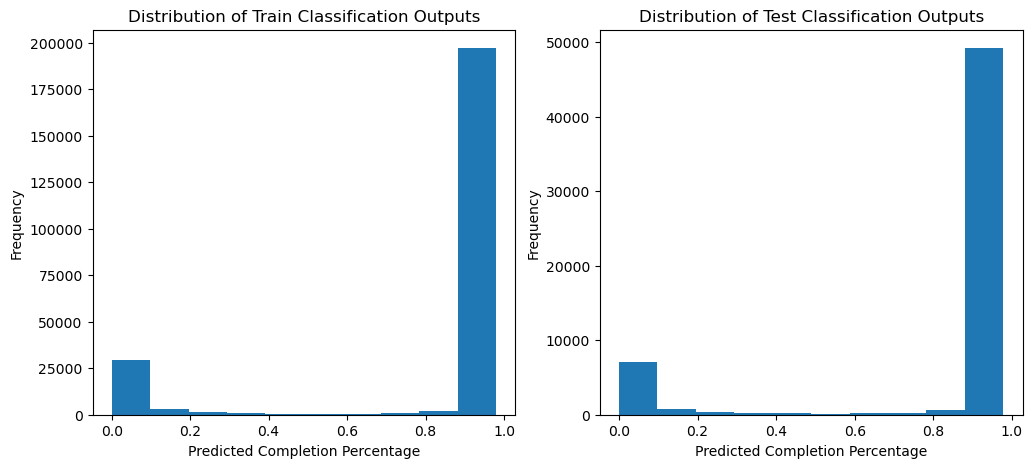

In [51]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.hist(train_pred_complete)

plt.xlabel("Predicted Completion Percentage")
plt.ylabel("Frequency")
plt.title("Distribution of Train Classification Outputs")

plt.subplot(1, 2, 2)

plt.hist(test_pred_complete)

plt.xlabel("Predicted Completion Percentage")
plt.ylabel("Frequency")
plt.title("Distribution of Test Classification Outputs")
plt.savefig(f"../outputs/images/competion_percentage_histogram_{EXPERIMENT_NAME}.png")

plt.show()

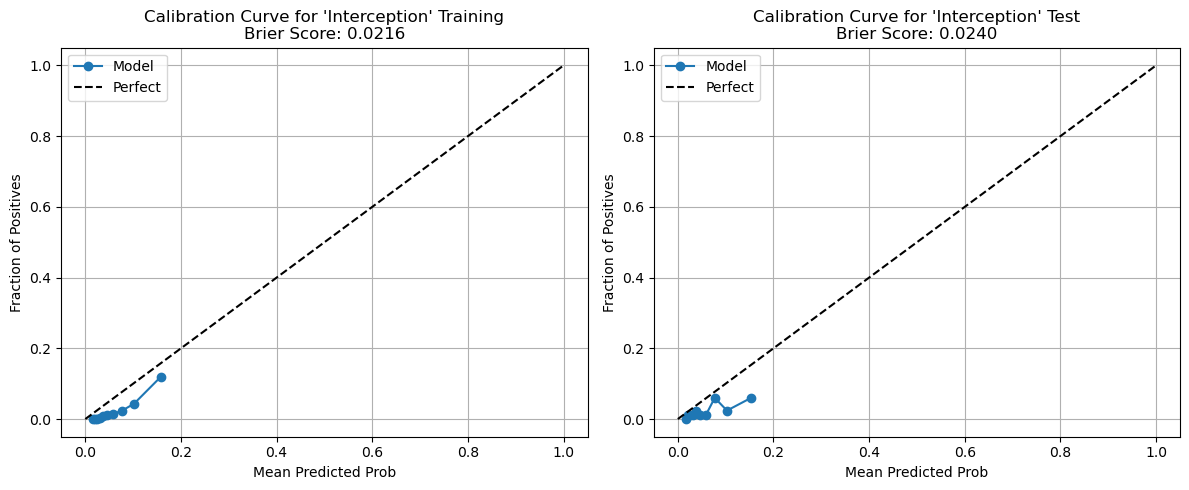

In [ ]:


train_true_interception = (yc_train == 2).astype(int)
train_prob_interception = train_probs[:, 2]

test_true_interception = (yc_test == 2).astype(int)
test_prob_interception = test_probs[:, 2]

frac_pos, mean_pred = calibration_curve(train_true_interception, train_prob_interception, n_bins=10, strategy='quantile')
brier = brier_score_loss(train_true_interception, train_prob_interception)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mean_pred, frac_pos, 'o-', label="Model")
plt.plot([0, 1], [0, 1], 'k--', label="Perfect")
plt.title(f"Calibration Curve for 'Interception' Training\nBrier Score: {brier:.4f}")
plt.xlabel("Mean Predicted Prob")
plt.ylabel("Fraction of Positives")
plt.grid(True)
plt.legend()


frac_pos, mean_pred = calibration_curve(test_true_interception, test_prob_interception, n_bins=10, strategy='quantile')
brier = brier_score_loss(test_true_interception, test_prob_interception)


plt.subplot(1, 2, 2)
plt.plot(mean_pred, frac_pos, 'o-', label="Model")
plt.plot([0, 1], [0, 1], 'k--', label="Perfect")
plt.title(f"Calibration Curve for 'Interception' Test\nBrier Score: {brier:.4f}")
plt.xlabel("Mean Predicted Prob")
plt.ylabel("Fraction of Positives")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig(f"../outputs/images/interception_calibration_{EXPERIMENT_NAME}.png")

plt.show()


In [ ]:
train_true_interception.mean(), train_prob_interception.mean()

(0.022581127560939135, 0.056989282)

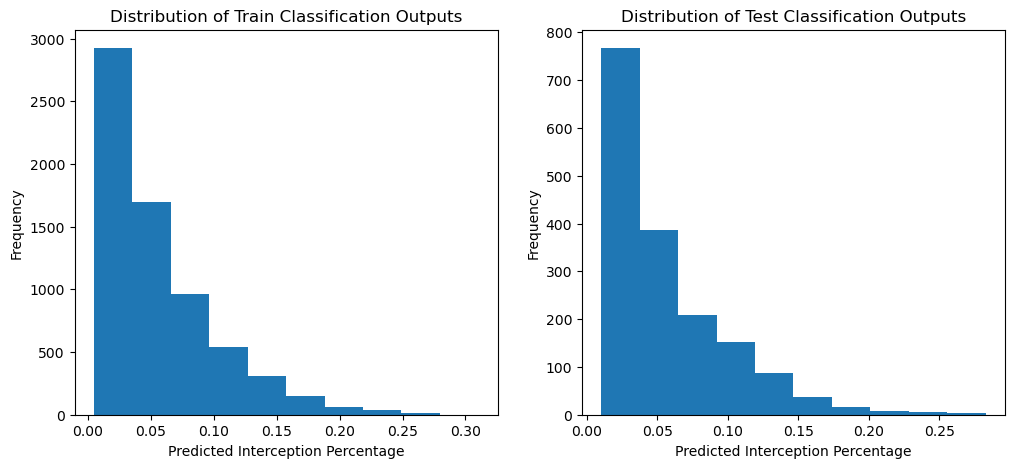

In [ ]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.hist(train_prob_interception)

plt.xlabel("Predicted Interception Percentage")
plt.ylabel("Frequency")
plt.title("Distribution of Train Classification Outputs")

plt.subplot(1, 2, 2)

plt.hist(test_prob_interception)

plt.xlabel("Predicted Interception Percentage")
plt.ylabel("Frequency")
plt.title("Distribution of Test Classification Outputs")
plt.savefig(f"../outputs/images/interception_histogram_{EXPERIMENT_NAME}.png")

plt.show()

### Regression scatter plot + correlation

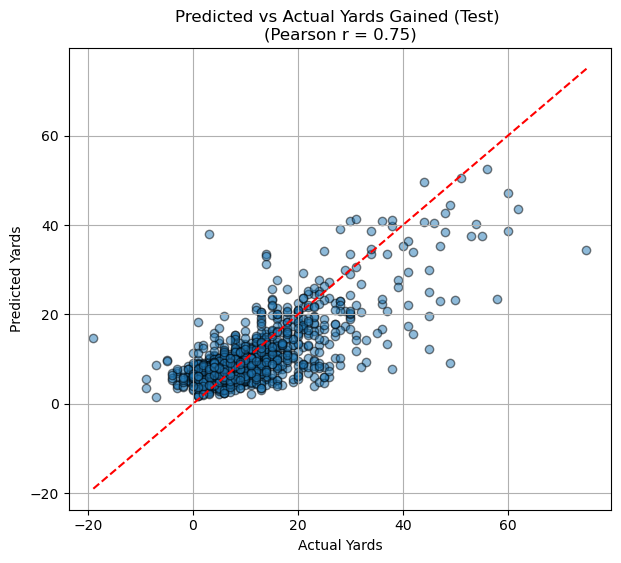

In [ ]:
reg_model.eval()
with torch.no_grad():
    r_preds = reg_model(Xr_test_tensor).squeeze().numpy()

from scipy.stats import pearsonr
r_corr, _ = pearsonr(yr_test, r_preds)

plt.figure(figsize=(7, 6))
plt.scatter(yr_test, r_preds, alpha=0.5, edgecolors='k')
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--')
plt.title(f"Predicted vs Actual Yards Gained (Test) \n(Pearson r = {r_corr:.2f})")
plt.xlabel("Actual Yards")
plt.ylabel("Predicted Yards")
plt.grid(True)
plt.savefig(f"../outputs/images/yards_gained_linear_coorelation_{EXPERIMENT_NAME}.png")

plt.show()


(array([ 18.,  48.,  91., 141., 190., 176., 115.,  59.,  39.,  39.,  31.,
         25.,  20.,  16.,  19.,  17.,  15.,   7.,   8.,   4.,   4.,   3.,
          3.,   1.,   1.,   8.,   2.,   1.,   4.,   3.,   6.,   2.,   2.,
          1.,   0.,   1.,   0.,   1.,   1.,   1.]),
 array([ 1.60511982,  2.88004518,  4.15497017,  5.42989588,  6.70482111,
         7.97974634,  9.2546711 , 10.52959633, 11.80452156, 13.07944775,
        14.35437298, 15.62929821, 16.90422249, 18.17914772, 19.45407295,
        20.72899818, 22.00392342, 23.27884865, 24.55377388, 25.82870102,
        27.10362625, 28.37855148, 29.65347672, 30.92840195, 32.20332718,
        33.47825241, 34.75317764, 36.02810287, 37.30302811, 38.57795334,
        39.85287857, 41.1278038 , 42.40272903, 43.67765427, 44.9525795 ,
        46.22750473, 47.50242996, 48.77735519, 50.05228043, 51.32720566,
        52.60213089]),
 <BarContainer object of 40 artists>)

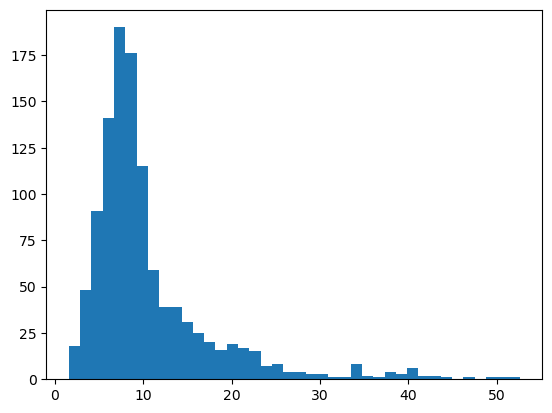

In [ ]:
plt.hist(r_preds, bins=40)

(array([  1.,   0.,   0.,   0.,   2.,   4.,  11.,  17., 104., 102., 159.,
        216., 100.,  84.,  91.,  38.,  33.,  46.,  23.,  13.,  21.,   9.,
          6.,   7.,   5.,   7.,   2.,   5.,   6.,   2.,   1.,   3.,   1.,
          2.,   1.,   0.,   0.,   0.,   0.,   1.]),
 array([-19.  , -16.65, -14.3 , -11.95,  -9.6 ,  -7.25,  -4.9 ,  -2.55,
         -0.2 ,   2.15,   4.5 ,   6.85,   9.2 ,  11.55,  13.9 ,  16.25,
         18.6 ,  20.95,  23.3 ,  25.65,  28.  ,  30.35,  32.7 ,  35.05,
         37.4 ,  39.75,  42.1 ,  44.45,  46.8 ,  49.15,  51.5 ,  53.85,
         56.2 ,  58.55,  60.9 ,  63.25,  65.6 ,  67.95,  70.3 ,  72.65,
         75.  ]),
 <BarContainer object of 40 artists>)

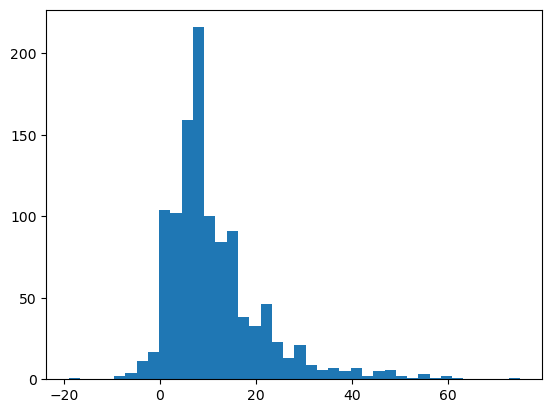

In [ ]:
plt.hist(yr_test, bins=40)


In [ ]:
yr_test.mean(), r_preds.mean()

(11.311665182546749, 10.668527)

In [ ]:
abs(yr_test - r_preds).mean()

4.68359041415679

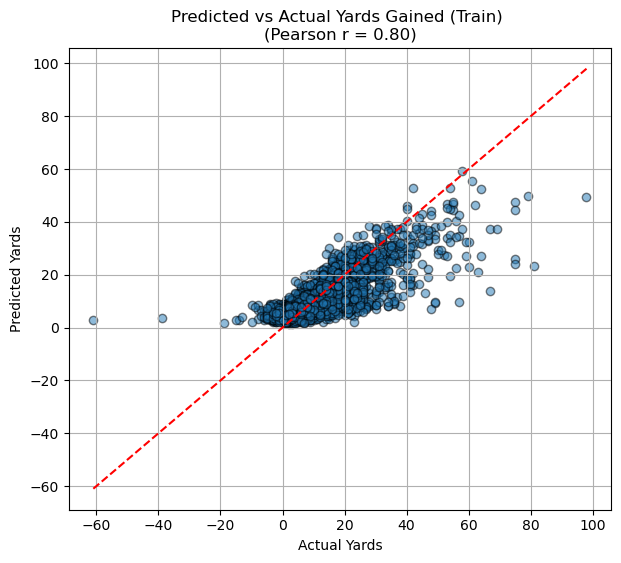

In [ ]:
reg_model.eval()
with torch.no_grad():
    r_preds = reg_model(Xr_train_tensor).squeeze().numpy()

from scipy.stats import pearsonr
r_corr, _ = pearsonr(yr_train, r_preds)

plt.figure(figsize=(7, 6))
plt.scatter(yr_train, r_preds, alpha=0.5, edgecolors='k')
plt.plot([yr_train.min(), yr_train.max()], [yr_train.min(), yr_train.max()], 'r--')
plt.title(f"Predicted vs Actual Yards Gained (Train) \n(Pearson r = {r_corr:.2f})")
plt.xlabel("Actual Yards")
plt.ylabel("Predicted Yards")
plt.grid(True)
plt.show()

In [ ]:
yr_train.mean(), r_preds.mean()

(10.927426536064115, 10.235138)

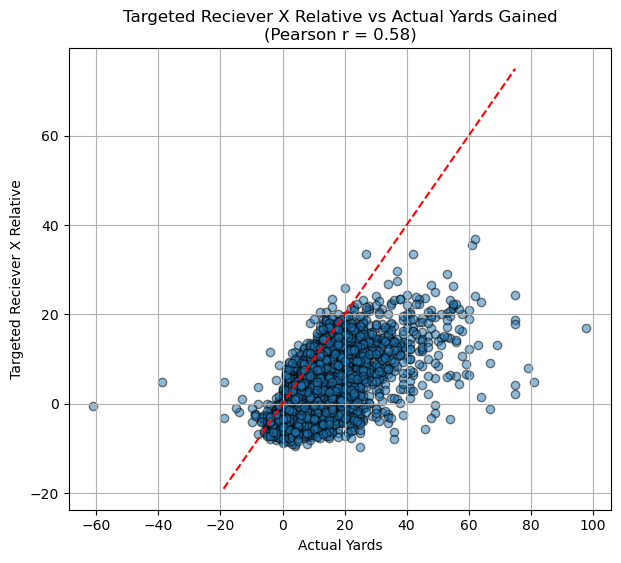

In [ ]:
from scipy.stats import pearsonr
completed = features[features["pass_result"] == "C"]
r_corr, _ = pearsonr(completed["yards_gained"], completed["target_x_relative"])

plt.figure(figsize=(7, 6))
plt.scatter(completed["yards_gained"], completed["target_x_relative"], alpha=0.5, edgecolors='k')
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--')
plt.title(f"Targeted Reciever X Relative vs Actual Yards Gained\n(Pearson r = {r_corr:.2f})")
plt.xlabel("Actual Yards")
plt.ylabel("Targeted Reciever X Relative")
plt.grid(True)
plt.show()

# QB Analysis


In [ ]:
from collections import defaultdict

qb_metrics = defaultdict(dict)

# Get unique QB ids
features['player_0_nflId'] = pd.to_numeric(features['player_0_nflId'], errors='coerce')

qb_ids = features["player_0_nflId"].astype(int).unique()


In [ ]:
qb_ids

array([52461, 29851, 52414, 43291, 53430, 43290, 46070, 44822, 33099,
       52413, 43424, 33084, 44814, 25511, 43380, 52409, 46076, 42344,
       53440, 45536, 46101, 53432, 42345, 38605, 39987, 52434, 41265,
       38538, 34452, 53496, 53444, 47784, 38632, 47789, 47980, 41291,
       38937, 54551, 41258, 37110, 54485, 53431, 37255, 54602, 34843,
       54712, 45159, 45244, 52530, 48090, 42831, 54727, 33138, 53647,
       47916, 47961, 43490])

In [ ]:
for qb_id in qb_ids:
    # Filter rows for this QB
    qb_mask = features["player_0_nflId"] == qb_id
    qb_rows = Xc_s[qb_mask]
    
    if len(qb_rows) == 0:
        continue

    # Get relevant model inputs
    X_clf_qb = Xc_s[qb_mask]
    y_true_class = y_clf_enc[qb_mask]

    qb_mask = reg_df["player_0_nflId"] == qb_id
    X_reg_qb = Xr_s[qb_mask]
    y_true_reg = y_reg[qb_mask].reset_index(drop=True)

    # Convert to tensor
    X_clf_tensor = torch.tensor(X_clf_qb, dtype=torch.float32)
    X_reg_tensor = torch.tensor(X_reg_qb, dtype=torch.float32)


    # Run through model
    with torch.no_grad():
        logits = clf_model(X_clf_tensor)
        yards_pred = reg_model(X_reg_tensor)
        probs = torch.softmax(logits, dim=1).numpy()
        class_preds = torch.argmax(logits, dim=1).numpy()
        reg_preds = yards_pred.squeeze().numpy()
    
    # === Completion Metrics ===
    actual_completion = (y_true_class == 0).mean()
    expected_completion = probs[:, 0].mean()

    # === Yards Gained ===
    actual_yards = y_true_reg.mean()
    expected_yards = reg_preds.mean()

    # === Save Basic Metrics ===
    qb_metrics[qb_id]["actual_completion"] = actual_completion
    qb_metrics[qb_id]["expected_completion"] = expected_completion
    qb_metrics[qb_id]["actual_yards"] = actual_yards
    qb_metrics[qb_id]["expected_yards"] = expected_yards
    qb_metrics[qb_id]["total_throws"] = len(X_clf_qb)



C:\Users\jesse\AppData\Local\Temp\ipykernel_24040\136520587.py:36: RuntimeWarning: Mean of empty slice.
  expected_yards = reg_preds.mean()
c:\Users\jesse\anaconda3\envs\nflenv\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:

features["player_5_position"].value_counts()


player_5_position
T    8359
Name: count, dtype: int64

In [ ]:
for qb_id in qb_ids:
    qb_mask = features["player_0_nflId"] == qb_id
    qb_rows = Xc_s[qb_mask]
    
    if len(qb_rows) == 0:
        continue

    # === Classification rows ===
    X_clf_qb = Xc_s[qb_mask]
    y_true_class = y_clf_enc[qb_mask]

    # === Regression rows (only completions) ===
    qb_mask_reg = reg_df["player_0_nflId"] == qb_id
    X_reg_qb = Xr_s[qb_mask_reg]
    y_true_reg = y_reg[qb_mask_reg].reset_index(drop=True)

    # Convert to tensors
    X_clf_tensor = torch.tensor(X_clf_qb, dtype=torch.float32)
    X_reg_tensor = torch.tensor(X_reg_qb, dtype=torch.float32)
    if len(X_reg_tensor) < 10:
        continue

    with torch.no_grad():
        logits = clf_model(X_clf_tensor)
        yards_pred = reg_model(X_reg_tensor)

        probs = torch.softmax(logits, dim=1).numpy()
        class_preds = torch.argmax(logits, dim=1).numpy()
        reg_preds = yards_pred.squeeze().numpy()

    # === Completion metrics ===
    actual_completion = (y_true_class == 0).mean()
    expected_completion = probs[:, 0].mean()

    # === Interception metrics ===
    actual_interception = (y_true_class == 2).mean()
    expected_interception = probs[:, 2].mean()

    # === Yards gained metrics ===
    actual_yards = y_true_reg.mean() if len(y_true_reg) > 0 else 0.0
    expected_yards = reg_preds.mean() if len(reg_preds) > 0 else 0.0

    # === Save all metrics ===
    qb_metrics[qb_id]["total_throws"] = len(X_clf_qb)

    qb_metrics[qb_id]["actual_completion"] = actual_completion
    qb_metrics[qb_id]["expected_completion"] = expected_completion

    qb_metrics[qb_id]["actual_interception"] = actual_interception
    qb_metrics[qb_id]["expected_interception"] = expected_interception

    qb_metrics[qb_id]["actual_yards"] = actual_yards
    qb_metrics[qb_id]["expected_yards"] = expected_yards


In [ ]:
X_clf_index = X_clf.index
X_reg_index = X_reg.index

Xc_s_df = pd.DataFrame(Xc_s, index=X_clf_index, columns=X_clf.columns)

Xr_s_df = pd.DataFrame(Xr_s, index=X_reg_index, columns=X_reg.columns)


In [ ]:
receiver_range = range(1, 6)
receiver_attrs = ['x', 'x_relative', 'y', 's', 'a', 'dis', 'o', 'dir']
real_results = []
fake_results = []
targeted_indexes = []
optimal_indexes = []

for qb_id in qb_ids:
    qb_mask = features["player_0_nflId"] == qb_id
    qb_rows = Xc_s_df[qb_mask].copy()

    total_plays = 0
    optimal_target_count = 0
    efficiency_sum = 0
    optimal_sum = 0

    for _, row in qb_rows.iterrows():
        target_idx = features.loc[row.name]["target_receiver_index"]
        if not 0 <= target_idx <= 4:
            continue  # skip invalid

        base_input = Xc_s_df.loc[row.name].copy()  # original row

        candidate_values = []

        for i in range(5):
            receiver_idx = i + 6
            modified_row = base_input.copy()

            for attr in receiver_attrs:
                modified_row[f'target_{attr}'] = row[f'player_{receiver_idx}_{attr}']

            # Model prediction
            inp = torch.tensor(modified_row.values.reshape(1, -1), dtype=torch.float32)
            with torch.no_grad():
                output = clf_model(inp)
                class_probs = torch.softmax(output, dim=1)
                yp = reg_model(inp)
                candidate_values.append(yp.item() * class_probs[0, 0])
                if i == target_idx:
                    real_results.append([yp.item(), class_probs[0, 0]])
                else:
                    fake_results.append([yp.item(), class_probs[0, 0]])

        actual_value = candidate_values[target_idx].item()
        optimal_value = max(candidate_values).item()

        optimal_sum += optimal_value
        targeted_indexes.append(target_idx)
        optimal_indexes.append(np.argmax(candidate_values))

        if np.argmax(candidate_values) == target_idx:
            optimal_target_count += 1

        if optimal_value > 0:
            efficiency_sum += actual_value / optimal_value

        total_plays += 1

    if total_plays > 0:
        qb_metrics[qb_id]["decision_efficiency_ratio"] = efficiency_sum / total_plays
        qb_metrics[qb_id]["optimal_target_rate"] = optimal_target_count / total_plays
        qb_metrics[qb_id]["average_optimal"] = optimal_sum / total_plays



(array([1878.,    0., 1920.,    0.,    0., 1539.,    0., 1551.,    0.,
        1471.]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

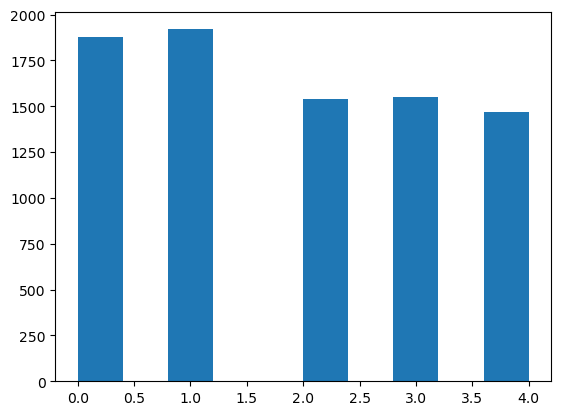

In [ ]:
plt.hist(optimal_indexes)

In [ ]:
# Create DataFrame from metrics
qb_results_df = pd.DataFrame.from_dict(qb_metrics, orient="index")
qb_results_df.reset_index(inplace=True)
qb_results_df.rename(columns={"index": "qb_nflId"}, inplace=True)

# Map QB display names using features
qb_id_to_name = old_features.set_index("player_0_nflId")["player_0_displayName_x"].to_dict()
qb_results_df["qb_name"] = qb_results_df["qb_nflId"].map(qb_id_to_name)

# Add CPOE and YOE
qb_results_df["completion_over_expected"] = qb_results_df["actual_completion"] - qb_results_df["expected_completion"]
qb_results_df["yards_over_expected"] = qb_results_df["actual_yards"] - qb_results_df["expected_yards"]

# Filter QBs with at least 150 throws
qb_filtered = qb_results_df[qb_results_df["total_throws"] >= 100]

# Sort by completion over expected

# View top 10


In [ ]:
qb_sorted = qb_filtered.sort_values("expected_interception", ascending=False)
#inlcude time to throw average. 

qb_sorted["qb_nflId"] = qb_sorted["qb_nflId"].astype(int)
qb_sorted[["qb_name", "qb_nflId","actual_completion", "expected_completion","completion_over_expected", "expected_yards", "yards_over_expected","average_optimal","optimal_target_rate", "decision_efficiency_ratio","actual_interception","expected_interception","total_throws"]]

qb_sorted[["qb_name", "completion_over_expected", "expected_yards", "yards_over_expected","actual_interception","expected_interception","total_throws"]]

,qb_name,completion_over_expected,expected_yards,yards_over_expected,actual_interception,expected_interception,total_throws
17,Jameis Winston,0.04283,12.28,-0.4696,0.04762,0.07129,105
8,Joe Flacco,-0.01052,9.477,-0.02839,0.02174,0.06454,138
9,Tua Tagovailoa,0.07389,12.25,0.9007,0.01463,0.06444,205
12,Mitchell Trubisky,-0.006484,11.27,-1.347,0.01667,0.06395,120
19,Cooper Rush,-0.01848,10.59,0.9291,0.02027,0.06389,148
5,Jared Goff,0.03206,10.17,2.003,0.02811,0.06296,249
6,Baker Mayfield,-0.06214,10.66,1.415,0.02721,0.06248,147
20,Lamar Jackson,0.02851,10.59,0.5512,0.02553,0.06203,235
26,Derek Carr,0.03769,10.48,0.207,0.01953,0.0618,256
18,Justin Fields,-0.04252,10.69,0.7521,0.0289,0.06177,173


In [ ]:


# Round to 3 significant figures in display
pd.set_option('display.float_format', lambda x: '{:.4g}'.format(x))

# Select desired columns
df_to_print = qb_sorted[["qb_name", "completion_over_expected"	 ]].head(5)

# Print without index
print(df_to_print.to_string(index=False))



       qb_name  completion_over_expected
Tua Tagovailoa                   0.07389
    Geno Smith                   0.07286
    Joe Burrow                   0.06844
     Matt Ryan                   0.05887
   Jalen Hurts                   0.05846


## Create and save predictions for all plays with all frames


In [ ]:
    
features[features["game_id"] == 2022091200]["play_id"].unique()

array([3574., 1465.,  109.,  286., 2093., 3491., 1344.,  565., 1320.,
       3001., 2244., 3048., 1579., 2268., 1764.,  201., 3296., 3101.,
       1241., 1487.,  401., 3382., 1793., 2038., 2688., 2801., 3216.,
       2009., 3325., 1550., 2500.,   85., 2188.,  156., 1521., 3267.,
       1028., 2522., 3747.,  786., 1004.,  346.,  664., 2750., 3125.,
       3149., 3628., 2546., 3723.,  467.,  762., 3826., 2591., 1725.,
       3245., 2779., 1851.,  688., 1680., 3194.,  931., 3467., 1057.,
        264., 3596., 1217., 1409., 3404.])

In [ ]:
features.sort_values(by="yards_gained")[["game_id", "play_id", "yards_gained"]].astype(int).head(10)


,game_id,play_id,yards_gained
1456,2022091811,4519,-61
8024,2022110600,2183,-39
4866,2022100901,2727,-19
7409,2022103002,2935,-19
2291,2022092506,3745,-15
2253,2022092512,1320,-15
765,2022091200,2546,-14
4891,2022100907,3783,-13
7136,2022103008,1425,-10
287,2022091100,3554,-10


In [ ]:
features

,player_0_nflId,player_0_displayName_x,player_0_position,player_0_x,player_0_x_relative,player_0_y,player_0_s,player_0_a,player_0_dis,player_0_o,...,target_route_FLAT,target_route_GO,target_route_HITCH,target_route_IN,target_route_OUT,target_route_POST,target_route_SCREEN,target_route_SLANT,target_route_WHEEL,frames_from_snap
0,5.246e+04,Jalen Hurts,QB,38.3,-6.7,27.87,1.58,0.44,0.16,179.3,...,0,0,0,0,0,0,1,0,0,15
1,2.985e+04,Aaron Rodgers,QB,26.75,-8.25,39.46,5.43,1.05,0.55,94.31,...,0,0,0,0,0,0,0,0,0,45
2,5.241e+04,Justin Herbert,QB,51.18,-5.82,22.2,2.64,1.03,0.27,108.8,...,0,0,0,0,0,0,0,0,0,35
3,4.329e+04,Carson Wentz,QB,28.98,-6.02,28.89,1.34,0.2,0.13,176.9,...,0,0,0,0,0,0,1,0,0,15
4,5.343e+04,Trevor Lawrence,QB,100.8,-6.24,17.14,7.65,2.38,0.77,129.3,...,1,0,0,0,0,0,0,0,0,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8354,4.61e+04,Lamar Jackson,QB,20.65,-10.35,24.91,0.83,0.36,0.09,139.4,...,0,0,0,0,0,0,0,0,0,41
8355,4.482e+04,Patrick Mahomes,QB,58.18,-5.82,24.39,2.33,0.29,0.22,46.34,...,0,0,0,0,0,0,1,0,0,13
8356,5.344e+04,Mac Jones,QB,61.61,-5.39,23.47,0.95,3.09,0.11,170.7,...,0,0,0,0,1,0,0,0,0,20
8357,5.241e+04,Justin Herbert,QB,60.85,-8.15,28.94,1.64,0.69,0.16,135.9,...,0,0,0,0,0,0,0,0,0,30


In [ ]:
features

,player_0_nflId,player_0_displayName_x,player_0_position,player_0_x,player_0_x_relative,player_0_y,player_0_s,player_0_a,player_0_dis,player_0_o,...,target_route_FLAT,target_route_GO,target_route_HITCH,target_route_IN,target_route_OUT,target_route_POST,target_route_SCREEN,target_route_SLANT,target_route_WHEEL,frames_from_snap
0,5.246e+04,Jalen Hurts,QB,38.3,-6.7,27.87,1.58,0.44,0.16,179.3,...,0,0,0,0,0,0,1,0,0,15
1,2.985e+04,Aaron Rodgers,QB,26.75,-8.25,39.46,5.43,1.05,0.55,94.31,...,0,0,0,0,0,0,0,0,0,45
2,5.241e+04,Justin Herbert,QB,51.18,-5.82,22.2,2.64,1.03,0.27,108.8,...,0,0,0,0,0,0,0,0,0,35
3,4.329e+04,Carson Wentz,QB,28.98,-6.02,28.89,1.34,0.2,0.13,176.9,...,0,0,0,0,0,0,1,0,0,15
4,5.343e+04,Trevor Lawrence,QB,100.8,-6.24,17.14,7.65,2.38,0.77,129.3,...,1,0,0,0,0,0,0,0,0,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8354,4.61e+04,Lamar Jackson,QB,20.65,-10.35,24.91,0.83,0.36,0.09,139.4,...,0,0,0,0,0,0,0,0,0,41
8355,4.482e+04,Patrick Mahomes,QB,58.18,-5.82,24.39,2.33,0.29,0.22,46.34,...,0,0,0,0,0,0,1,0,0,13
8356,5.344e+04,Mac Jones,QB,61.61,-5.39,23.47,0.95,3.09,0.11,170.7,...,0,0,0,0,1,0,0,0,0,20
8357,5.241e+04,Justin Herbert,QB,60.85,-8.15,28.94,1.64,0.69,0.16,135.9,...,0,0,0,0,0,0,0,0,0,30


In [ ]:
features["yards_gained"].mean()

7.391912908242613

In [ ]:
378 / 8359 / 2

0.022610360090919965